### Lifecycle Aggregation Using Phase-3 Inference Energy

In [1]:
import pandas as pd

# ============================================================
# Phase-3 LOCKED CONSTANTS (Inference Measurement)
# ============================================================

TEST_SET_SIZE = 10_000          # CIFAR-10 test images
INFERENCE_REPEATS = 10          # Extended inference window
TOTAL_INFERENCES = TEST_SET_SIZE * INFERENCE_REPEATS

# Deployment scales (Phase-4 LOCK)
N_VALUES = [1_000, 10_000, 100_000, 1_000_000]

# ============================================================
# Phase-3: Inference-only statistics (CSV-locked)
# ============================================================

phase3_inference_stats = {
    ("ResNet-18", "FP32"): {
        "mean_power_w": 67.27,
        "duration_s": 22.18,
        "accuracy": 0.9461   # Phase-1 accuracy
    },
    ("ResNet-18", "FP16"): {
        "mean_power_w": 64.75,
        "duration_s": 15.73,
        "accuracy": 0.9461
    },
    ("MobileNet-V2", "FP32"): {
        "mean_power_w": 35.68,
        "duration_s": 15.77,
        "accuracy": 0.8389
    },
    ("MobileNet-V2", "FP16"): {
        "mean_power_w": 36.76,
        "duration_s": 16.27,
        "accuracy": 0.8389
    },
}

# ============================================================
# Phase-1: Accuracy-only training energy (mean values)
# ============================================================

training_energy = {
    "ResNet-18": 370_970,      # Joules (370.97 kJ)
    "MobileNet-V2": 115_140,   # Joules (115.14 kJ)
}

# ============================================================
# Phase-4: Lifecycle aggregation
# ============================================================

rows = []

for (model, precision), stats in phase3_inference_stats.items():

    # Phase-3 per-inference energy (J / inference)
    E_inf = (stats["mean_power_w"] * stats["duration_s"]) / TOTAL_INFERENCES
    acc = stats["accuracy"]
    E_train = training_energy[model]

    for N in N_VALUES:
        E_total = E_train + N * E_inf
        ECP = E_total / (N * acc)

        rows.append({
            "Model": model,
            "Train Regime": "Accuracy-optimal (Phase-1)",
            "Inference Mode": precision,
            "N": N,
            "Accuracy": acc,
            "E_train (J)": E_train,
            "E_inf (J)": E_inf,
            "E_total (J)": E_total,
            "ECP (J/correct)": ECP
        })

df = pd.DataFrame(rows)

# ============================================================
# Ranking (Lower ECP = Better)
# ============================================================

df["Rank"] = (
    df.groupby("N")["ECP (J/correct)"]
      .rank(method="min")
      .astype(int)
)

df = df.sort_values(by=["N", "Rank", "Model"])

# ============================================================
# Save Phase-4 Core Artifact
# ============================================================

output_path = "phase4_lifecycle_table.csv"
df.to_csv(output_path, index=False)

print("Phase-4.1 lifecycle table saved to:", output_path)
print(df)


Phase-4.1 lifecycle table saved to: phase4_lifecycle_table.csv
           Model                Train Regime Inference Mode        N  \
8   MobileNet-V2  Accuracy-optimal (Phase-1)           FP32     1000   
12  MobileNet-V2  Accuracy-optimal (Phase-1)           FP16     1000   
4      ResNet-18  Accuracy-optimal (Phase-1)           FP16     1000   
0      ResNet-18  Accuracy-optimal (Phase-1)           FP32     1000   
9   MobileNet-V2  Accuracy-optimal (Phase-1)           FP32    10000   
13  MobileNet-V2  Accuracy-optimal (Phase-1)           FP16    10000   
5      ResNet-18  Accuracy-optimal (Phase-1)           FP16    10000   
1      ResNet-18  Accuracy-optimal (Phase-1)           FP32    10000   
10  MobileNet-V2  Accuracy-optimal (Phase-1)           FP32   100000   
14  MobileNet-V2  Accuracy-optimal (Phase-1)           FP16   100000   
6      ResNet-18  Accuracy-optimal (Phase-1)           FP16   100000   
2      ResNet-18  Accuracy-optimal (Phase-1)           FP32   100000   
1

### Ranking Inversions & ECP Curves (CORE EVIDENCE)

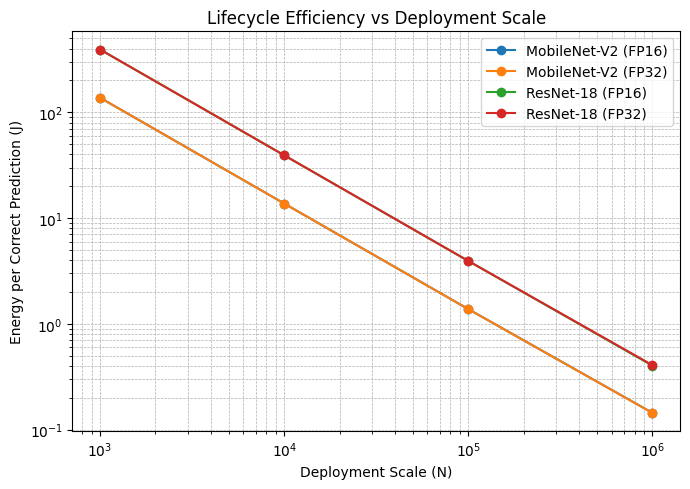

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("phase4_lifecycle_table.csv")

plt.figure(figsize=(7,5))

for (model, mode), g in df.groupby(["Model", "Inference Mode"]):
    plt.plot(
        g["N"],
        g["ECP (J/correct)"],
        marker="o",
        label=f"{model} ({mode})"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Deployment Scale (N)")
plt.ylabel("Energy per Correct Prediction (J)")
plt.title("Lifecycle Efficiency vs Deployment Scale")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()


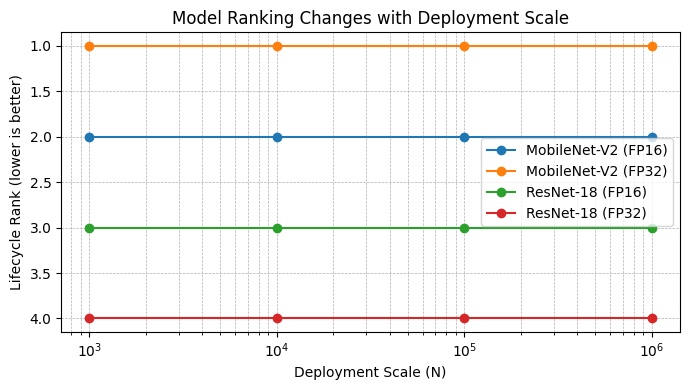

In [3]:
plt.figure(figsize=(7,4))

for (model, mode), g in df.groupby(["Model", "Inference Mode"]):
    plt.plot(
        g["N"],
        g["Rank"],
        marker="o",
        label=f"{model} ({mode})"
    )

plt.xscale("log")
plt.gca().invert_yaxis()  # Rank 1 at top
plt.xlabel("Deployment Scale (N)")
plt.ylabel("Lifecycle Rank (lower is better)")
plt.title("Model Ranking Changes with Deployment Scale")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()
